# Filtrar HF FoodSeg103 → 20 classes core

Filtra o dataset HF mantendo apenas imagens com classes mapeadas pras 20 classes finais do NutriSnap.

**Lógica:**
- Mapeia 17 classes do HF → 17 das 20 classes brasileiras (purê, farofa, mandioca virão de outras fontes)
- Pra cada imagem: filtra anotações fora do mapa, mantém imagem se sobrar pelo menos 1 anotação
- Reescreve labels com novos IDs (0-19)
- Salva dataset filtrado em /content/dataset_filtered/

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
ZIP_PATH = '/content/drive/MyDrive/nutrition_planner/data.zip'

import os
if not os.path.exists('/content/dataset/data'):
    !mkdir -p /content/dataset
    !unzip -q -o {ZIP_PATH} -d /content/dataset/
!ls /content/dataset/data/

dataset.yaml  images  labels


In [3]:
import yaml

with open('/content/dataset/data/dataset.yaml') as f:
    cfg = yaml.safe_load(f)

hf_class_names = cfg['names']
print(f"HF tem {len(hf_class_names)} classes")
print(f"Primeiras 20: {hf_class_names[:20]}")

HF tem 103 classes
Primeiras 20: ['candy', 'egg tart', 'french fries', 'chocolate', 'biscuit', 'popcorn', 'pudding', 'ice cream', 'cheese butter', 'cake', 'wine', 'milkshake', 'coffee', 'juice', 'milk', 'tea', 'almond', 'red beans', 'cashew', 'dried cranberries']


## 2. Definir as 20 classes finais e o mapeamento

In [4]:
# 20 classes finais (PT) na ordem que vai virar ID 0-19
FINAL_CLASSES = [
    'arroz',         # 0
    'feijão',        # 1
    'frango',        # 2
    'carne bovina',  # 3
    'peixe',         # 4
    'ovo',           # 5
    'carne suína',   # 6
    'batata frita',  # 7
    'batata cozida', # 8
    'purê',          # 9
    'farofa',        # 10
    'mandioca',      # 11
    'macarrão',      # 12
    'pão',           # 13
    'salada',        # 14
    'tomate',        # 15
    'cenoura',       # 16
    'brócolis',      # 17
    'repolho',       # 18
    'abóbora',       # 19
    'pizza',         # 20 
]

# Mapeamento: HF nome → classe PT
# (purê, farofa, mandioca não têm equivalente no HF)
HF_TO_PT = {
    'rice': 'arroz',
    'red beans': 'feijão',
    'chicken duck': 'frango',
    'steak': 'carne bovina',
    'fish': 'peixe',
    'egg': 'ovo',
    'pork': 'carne suína',
    'french fries': 'batata frita',
    'potato': 'batata cozida',
    'pasta': 'macarrão',
    'bread': 'pão',
    'salad': 'salada',
    'tomato': 'tomate',
    'carrot': 'cenoura',
    'broccoli': 'brócolis',
    'cabbage': 'repolho',
    'pumpkin': 'abóbora',
    'pizza': 'pizza',
}

# Pra cada nome HF, pega o índice no array hf_class_names
# Avisa se algum não bater
hf_id_to_new_id = {}
pt_to_new_id = {pt: i for i, pt in enumerate(FINAL_CLASSES)}

for hf_name, pt_name in HF_TO_PT.items():
    if hf_name not in hf_class_names:
        print(f"⚠️  '{hf_name}' não encontrado no HF - verifica nome correto")
        continue
    hf_id = hf_class_names.index(hf_name)
    new_id = pt_to_new_id[pt_name]
    hf_id_to_new_id[hf_id] = new_id

print(f"\n✅ Mapeamento criado: {len(hf_id_to_new_id)} classes do HF mapeadas")
print(f"\nMapeamento detalhado:")
for hf_id, new_id in sorted(hf_id_to_new_id.items()):
    print(f"  HF {hf_id} ({hf_class_names[hf_id]:20s}) → {new_id} ({FINAL_CLASSES[new_id]})")


✅ Mapeamento criado: 18 classes do HF mapeadas

Mapeamento detalhado:
  HF 2 (french fries        ) → 7 (batata frita)
  HF 17 (red beans           ) → 1 (feijão)
  HF 23 (egg                 ) → 5 (ovo)
  HF 45 (steak               ) → 3 (carne bovina)
  HF 46 (pork                ) → 6 (carne suína)
  HF 47 (chicken duck        ) → 2 (frango)
  HF 53 (fish                ) → 4 (peixe)
  HF 57 (bread               ) → 13 (pão)
  HF 60 (pizza               ) → 20 (pizza)
  HF 63 (pasta               ) → 12 (macarrão)
  HF 65 (rice                ) → 0 (arroz)
  HF 69 (potato              ) → 8 (batata cozida)
  HF 72 (tomato              ) → 15 (tomate)
  HF 80 (pumpkin             ) → 19 (abóbora)
  HF 83 (carrot              ) → 16 (cenoura)
  HF 86 (broccoli            ) → 17 (brócolis)
  HF 90 (cabbage             ) → 18 (repolho)
  HF 101 (salad               ) → 14 (salada)


## 3. Filtrar labels e copiar imagens

In [5]:
import shutil
from pathlib import Path
from tqdm import tqdm

OUT_ROOT = Path('/content/dataset_filtered/data')
for split in ['train', 'val']:
    (OUT_ROOT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / 'labels' / split).mkdir(parents=True, exist_ok=True)

def filter_label_file(input_path, output_path, hf_id_to_new_id):
    """Lê label HF, filtra linhas das classes mapeadas e reescreve com novos IDs.
    Retorna número de linhas mantidas."""
    if not os.path.exists(input_path):
        return 0
    
    kept_lines = []
    with open(input_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            old_id = int(parts[0])
            if old_id in hf_id_to_new_id:
                new_id = hf_id_to_new_id[old_id]
                new_line = f"{new_id} " + " ".join(parts[1:])
                kept_lines.append(new_line)
    
    if kept_lines:
        with open(output_path, 'w') as f:
            f.write("\n".join(kept_lines) + "\n")
        return len(kept_lines)
    return 0

# Roda em train e val
stats = {}
for split in ['train', 'val']:
    src_img_dir = f'/content/dataset/data/images/{split}'
    src_lbl_dir = f'/content/dataset/data/labels/{split}'
    out_img_dir = OUT_ROOT / 'images' / split
    out_lbl_dir = OUT_ROOT / 'labels' / split
    
    images = sorted(os.listdir(src_img_dir))
    n_kept = 0
    n_total = 0
    n_annotations = 0
    
    for img in tqdm(images, desc=split):
        n_total += 1
        stem = os.path.splitext(img)[0]
        src_label = f'{src_lbl_dir}/{stem}.txt'
        out_label = out_lbl_dir / f'{stem}.txt'
        
        kept = filter_label_file(src_label, out_label, hf_id_to_new_id)
        if kept > 0:
            # Copia imagem só se label sobrou
            shutil.copy(f'{src_img_dir}/{img}', out_img_dir / img)
            n_kept += 1
            n_annotations += kept
    
    stats[split] = {'kept': n_kept, 'total': n_total, 'annotations': n_annotations}
    print(f"\n{split}: {n_kept}/{n_total} imagens mantidas, {n_annotations} anotações")

print(f"\n📊 Total: {stats['train']['kept']} train, {stats['val']['kept']} val")

train: 100%|██████████| 4983/4983 [00:08<00:00, 595.95it/s] 



train: 3735/4983 imagens mantidas, 10934 anotações


val: 100%|██████████| 2135/2135 [00:01<00:00, 1387.70it/s]


val: 1607/2135 imagens mantidas, 4739 anotações

📊 Total: 3735 train, 1607 val


## 4. Distribuição de classes no dataset filtrado

In [6]:
from collections import Counter

for split in ['train', 'val']:
    counter = Counter()
    lbl_dir = OUT_ROOT / 'labels' / split
    for lbl_file in os.listdir(lbl_dir):
        with open(lbl_dir / lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    
    print(f"\n{split.upper()}:")
    for cls_id in range(len(FINAL_CLASSES)):
        n = counter.get(cls_id, 0)
        bar = '█' * min(n // 20, 40)
        print(f"  {cls_id:2d} {FINAL_CLASSES[cls_id]:15s} {n:5d}  {bar}")


TRAIN:
   0 arroz             628  ███████████████████████████████
   1 feijão             44  ██
   2 frango           1109  ████████████████████████████████████████
   3 carne bovina      941  ████████████████████████████████████████
   4 peixe             323  ████████████████
   5 ovo               305  ███████████████
   6 carne suína       608  ██████████████████████████████
   7 batata frita      189  █████████
   8 batata cozida     999  ████████████████████████████████████████
   9 purê                0  
  10 farofa              0  
  11 mandioca            0  
  12 macarrão          156  ███████
  13 pão              1616  ████████████████████████████████████████
  14 salada             12  
  15 tomate           1367  ████████████████████████████████████████
  16 cenoura          1378  ████████████████████████████████████████
  17 brócolis          942  ████████████████████████████████████████
  18 repolho           138  ██████
  19 abóbora           108  █████
  20 pizza 

## 5. Visualizar imagens com anotações

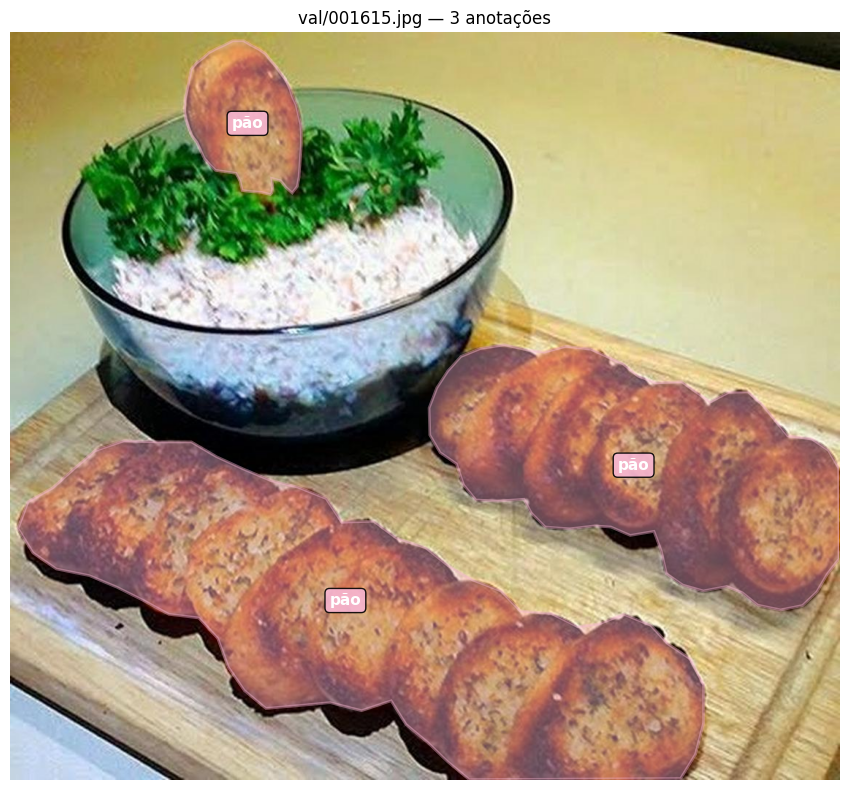

Classes: ['pão', 'pão', 'pão']


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

def visualize_sample(split='val', idx=None):
    """Mostra uma imagem do dataset filtrado com suas anotações."""
    img_dir = OUT_ROOT / 'images' / split
    lbl_dir = OUT_ROOT / 'labels' / split
    
    images = sorted(os.listdir(img_dir))
    if idx is None:
        idx = random.randint(0, len(images) - 1)
    
    img_name = images[idx]
    stem = os.path.splitext(img_name)[0]
    img = Image.open(img_dir / img_name).convert('RGB')
    w, h = img.size
    
    # Lê label
    annotations = []
    lbl_path = lbl_dir / f'{stem}.txt'
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue
                cls_id = int(parts[0])
                coords = list(map(float, parts[1:]))
                points = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
                annotations.append((cls_id, points))
    
    # Plota
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)
    
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    for cls_id, points in annotations:
        poly = patches.Polygon(points, closed=True, fill=True, 
                              facecolor=colors[cls_id], alpha=0.4,
                              edgecolor=colors[cls_id], linewidth=2)
        ax.add_patch(poly)
        cx = sum(p[0] for p in points) / len(points)
        cy = sum(p[1] for p in points) / len(points)
        ax.text(cx, cy, FINAL_CLASSES[cls_id], color='white', fontsize=11,
               weight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor=colors[cls_id], alpha=0.9))
    
    ax.set_title(f'{split}/{img_name} — {len(annotations)} anotações')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Classes: {[FINAL_CLASSES[c] for c, _ in annotations]}")

# Mostra uma aleatória
visualize_sample('val')

# Pra ver outra: visualize_sample('val', idx=10) ou rodar essa célula de novo

## 6. Gerar dataset.yaml e zipar

In [9]:
yaml_content = f"""path: /content/dataset_filtered/data
train: images/train
val: images/val

nc: {len(FINAL_CLASSES)}
names: {FINAL_CLASSES}
"""

with open(OUT_ROOT / 'dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("dataset.yaml:")
print(yaml_content)

dataset.yaml:
path: /content/dataset_filtered/data
train: images/train
val: images/val

nc: 21
names: ['arroz', 'feijão', 'frango', 'carne bovina', 'peixe', 'ovo', 'carne suína', 'batata frita', 'batata cozida', 'purê', 'farofa', 'mandioca', 'macarrão', 'pão', 'salada', 'tomate', 'cenoura', 'brócolis', 'repolho', 'abóbora', 'pizza']



In [10]:
# Zipa pra salvar no Drive
!cd /content/dataset_filtered && zip -qr /content/dataset_filtered.zip data/

# Move pro Drive
import shutil
shutil.copy('/content/dataset_filtered.zip', '/content/drive/MyDrive/nutrition_planner/dataset_filtered.zip')

print("✅ Salvo em /content/drive/MyDrive/nutrition_planner/dataset_filtered.zip")

✅ Salvo em /content/drive/MyDrive/nutrition_planner/dataset_filtered.zip


In [11]:
# =============================================================================
# Adicionar anotações Mendeley (150 imagens) ao dataset filtrado
# Split 80/20 (120 train + 30 val) das anotações novas
# =============================================================================

import os, shutil, random
from pathlib import Path

# Path do zip no Drive — AJUSTE se o nome for diferente
ANNOT_ZIP = '/content/drive/MyDrive/nutrition_planner/mendeley_annotated.zip'

# Descompacta
if not os.path.exists('/content/mendeley_annotated'):
    !mkdir -p /content/mendeley_annotated
    !unzip -q -o {ANNOT_ZIP} -d /content/mendeley_annotated/

# Detecta estrutura — espera que tenha output_images/ e output_labels/
src_root = Path('/content/mendeley_annotated')
# Pode estar dentro de uma pasta wrapper, procura
candidates = [src_root, src_root / 'mendeley_annotated', src_root / 'sam2_annotator']
src_imgs = src_lbls = None
for c in candidates:
    if (c / 'output_images').exists() and (c / 'output_labels').exists():
        src_imgs = c / 'output_images'
        src_lbls = c / 'output_labels'
        break

if src_imgs is None:
    print("⚠️ Não achei output_images/ e output_labels/. Estrutura do zip:")
    for root, dirs, files in os.walk(src_root):
        depth = root.replace(str(src_root), '').count(os.sep)
        if depth > 2:
            continue
        print(f"  {root}: dirs={dirs[:5]}, n_files={len(files)}")
    raise FileNotFoundError("Ajuste o caminho")

# Lista pares (imagem, label) — ignora .skipped e arquivos sem label correspondente
pairs = []
for lbl_file in sorted(os.listdir(src_lbls)):
    if not lbl_file.endswith('.txt'):
        continue
    stem = os.path.splitext(lbl_file)[0]
    # Procura imagem com mesmo nome (jpg/jpeg/png)
    img_file = None
    for ext in ['.jpg', '.jpeg', '.png']:
        if (src_imgs / f'{stem}{ext}').exists():
            img_file = f'{stem}{ext}'
            break
    if img_file:
        pairs.append((img_file, lbl_file))

print(f"Pares encontrados: {len(pairs)}")

# Split 80/20 (seed fixo pra ser reproduzível)
random.seed(42)
random.shuffle(pairs)
n_train = int(len(pairs) * 0.8)
train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:]
print(f"  Train: {len(train_pairs)}")
print(f"  Val:   {len(val_pairs)}")

# Copia pra dentro do dataset_filtered (que já está descompactado)
# Prefixo "mend_" pra não colidir com nomes do HF
DEST_ROOT = Path('/content/dataset_filtered/data')

n_added = {'train': 0, 'val': 0}
for split, split_pairs in [('train', train_pairs), ('val', val_pairs)]:
    for img_file, lbl_file in split_pairs:
        stem = os.path.splitext(img_file)[0]
        ext = os.path.splitext(img_file)[1]
        new_stem = f'mend_{stem}'
        
        shutil.copy(src_imgs / img_file, DEST_ROOT / 'images' / split / f'{new_stem}{ext}')
        shutil.copy(src_lbls / lbl_file, DEST_ROOT / 'labels' / split / f'{new_stem}.txt')
        n_added[split] += 1

print(f"\n✅ Adicionado: {n_added['train']} train + {n_added['val']} val")

# Conta totais finais
for split in ['train', 'val']:
    n = len(os.listdir(DEST_ROOT / 'images' / split))
    print(f"  {split} total: {n} imagens")

# Re-zipa pro Drive (versão com Mendeley)
!cd /content/dataset_filtered && zip -qr /content/dataset_filtered_v2.zip data/
shutil.copy('/content/dataset_filtered_v2.zip', '/content/drive/MyDrive/nutrition_planner/dataset_filtered_v2.zip')
print(f"\n💾 Salvo em /content/drive/MyDrive/nutrition_planner/dataset_filtered_v2.zip")

Pares encontrados: 151
  Train: 120
  Val:   31

✅ Adicionado: 120 train + 31 val
  train total: 3855 imagens
  val total: 1638 imagens

💾 Salvo em /content/drive/MyDrive/nutrition_planner/dataset_filtered_v2.zip


In [5]:
from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive/nutrition_planner/ | grep -i zip

Mounted at /content/drive
dataset_filtered_v2.zip
dataset_filtered.zip
data.zip
mendeley_annotated_v2.zip
mendeley_annotated.zip
mendeley.zip


In [4]:
import os
ZIP_V2 = '/content/drive/MyDrive/nutrition_planner/dataset_filtered_v2.zip'

if not os.path.exists('/content/dataset_filtered/data'):
    !mkdir -p /content/dataset_filtered
    !unzip -q -o {ZIP_V2} -d /content/dataset_filtered/

!ls /content/dataset_filtered/data/

dataset.yaml  images  labels


In [9]:
!ls /content/drive/MyDrive/nutrition_planner/

'Brazilian food images'    data.zip		       mendeley.zip   runs
 dataset_filtered_v2.zip   mendeley_annotated_v2.zip   prato1.jpg
 dataset_filtered.zip	   mendeley_annotated.zip      prato2.jpg


In [10]:
import os
ZIP_V2 = '/content/drive/MyDrive/nutrition_planner/dataset_filtered_v2.zip'

print("Existe?", os.path.exists(ZIP_V2))

!mkdir -p /content/dataset_filtered
!unzip -q -o "{ZIP_V2}" -d /content/dataset_filtered/
!ls /content/dataset_filtered/data/

Existe? True
dataset.yaml  images  labels


In [12]:
!unzip -l /content/drive/MyDrive/nutrition_planner/mendeley_annotated_v2.zip | head -20

Archive:  /content/drive/MyDrive/nutrition_planner/mendeley_annotated_v2.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-05-05 19:53   output_images/
    36716  2026-05-04 19:23   output_images/meal0128.jpg
    27374  2026-05-04 12:28   output_images/meal0100.jpg
    31177  2026-05-04 12:35   output_images/meal0114.jpg
    32328  2026-05-05 19:40   output_images/cassava_cassava0003.jpg
    20022  2026-05-05 15:51   output_images/mashed_prato122.jpg
    36290  2026-05-05 19:51   output_images/noodles_noodles0013.jpg
    32706  2026-05-05 19:48   output_images/noodles_noodles0007.jpg
    29078  2026-05-04 12:02   output_images/meal0048.jpg
    28028  2026-05-05 15:22   output_images/beans_beans0006.jpg
    33837  2026-05-04 12:15   output_images/meal0074.jpg
    37564  2026-05-04 12:11   output_images/meal0060.jpg
    35652  2026-05-05 15:29   output_images/beans_beans0012.jpg
    41095  2026-05-05 15:30   output_images/beans_beans0013.jpg
    33

In [13]:
import os, shutil
from pathlib import Path
from collections import Counter

# =============================================================================
# Sprint 5 — Adicionar APENAS as 283 anotações novas à validação
# =============================================================================

ANNOT_V2_ZIP = '/content/drive/MyDrive/nutrition_planner/mendeley_annotated_v2.zip'

# Descompacta (com -o pra sobrescrever se já existir)
!mkdir -p /content/mendeley_annotated_v2
!unzip -q -o "{ANNOT_V2_ZIP}" -d /content/mendeley_annotated_v2/

src_imgs = Path('/content/mendeley_annotated_v2/output_images')
src_lbls = Path('/content/mendeley_annotated_v2/output_labels')

# Sanity check
print(f"Imagens no zip: {len(os.listdir(src_imgs))}")
print(f"Labels no zip: {len(os.listdir(src_lbls))}")

# Filtra SÓ Sprint 5 (arquivos com prefixo de pasta Mendeley)
SPRINT5_PREFIXES = ('beans_', 'mashed_', 'farofa_', 'cassava_', 'noodles_', 'pastaredsauce_')

pairs = []
for lbl_file in sorted(os.listdir(src_lbls)):
    if not lbl_file.endswith('.txt'):
        continue
    if not lbl_file.startswith(SPRINT5_PREFIXES):
        continue  # pula Sprint 4 (meal0XXX) - já está no v2
    stem = os.path.splitext(lbl_file)[0]
    img_file = None
    for ext in ['.jpg', '.jpeg', '.png']:
        if (src_imgs / f'{stem}{ext}').exists():
            img_file = f'{stem}{ext}'
            break
    if img_file:
        pairs.append((img_file, lbl_file))

print(f"\nPares Sprint 5 detectados: {len(pairs)}")

# Adiciona TUDO na VAL (objetivo: ter contagem confiável)
DEST_ROOT = Path('/content/dataset_filtered/data')
n_added = 0
for img_file, lbl_file in pairs:
    stem = os.path.splitext(img_file)[0]
    ext = os.path.splitext(img_file)[1]
    new_stem = f'mend5_{stem}'
    
    shutil.copy(src_imgs / img_file, DEST_ROOT / 'images' / 'val' / f'{new_stem}{ext}')
    shutil.copy(src_lbls / lbl_file, DEST_ROOT / 'labels' / 'val' / f'{new_stem}.txt')
    n_added += 1

print(f"\n✅ Adicionado {n_added} imagens à VAL")

# Conta totais
for split in ['train', 'val']:
    n = len(os.listdir(DEST_ROOT / 'images' / split))
    print(f"  {split} total: {n}")

# Distribuição por classe na val
FINAL_CLASSES = [
    'arroz', 'feijão', 'frango', 'carne bovina', 'peixe',
    'ovo', 'carne suína', 'batata frita', 'batata cozida', 'purê',
    'farofa', 'mandioca', 'macarrão', 'pão', 'salada',
    'tomate', 'cenoura', 'brócolis', 'repolho', 'abóbora', 'pizza'
]

counter = Counter()
for lbl_file in os.listdir(DEST_ROOT / 'labels' / 'val'):
    with open(DEST_ROOT / 'labels' / 'val' / lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                counter[int(parts[0])] += 1

print("\n📊 Distribuição na VAL:")
for cls_id in range(len(FINAL_CLASSES)):
    n = counter.get(cls_id, 0)
    marker = ' ❌' if n < 30 else (' ⚠️' if n < 50 else ' ✅')
    bar = '█' * min(n // 20, 30)
    print(f"  {cls_id:2d} {FINAL_CLASSES[cls_id]:15s} {n:5d}{marker}  {bar}")

# Re-zipa e salva v3
!cd /content/dataset_filtered && zip -qr /content/dataset_filtered_v3.zip data/
shutil.copy('/content/dataset_filtered_v3.zip', '/content/drive/MyDrive/nutrition_planner/dataset_filtered_v3.zip')
print(f"\n💾 dataset_filtered_v3.zip salvo no Drive")

Imagens no zip: 273
Labels no zip: 283

Pares Sprint 5 detectados: 122

✅ Adicionado 122 imagens à VAL
  train total: 3855
  val total: 1760

📊 Distribuição na VAL:
   0 arroz             336 ✅  ████████████████
   1 feijão             85 ✅  ████
   2 frango            537 ✅  ██████████████████████████
   3 carne bovina      531 ✅  ██████████████████████████
   4 peixe             125 ✅  ██████
   5 ovo               107 ✅  █████
   6 carne suína       240 ✅  ████████████
   7 batata frita      101 ✅  █████
   8 batata cozida     390 ✅  ███████████████████
   9 purê               41 ⚠️  ██
  10 farofa             32 ⚠️  █
  11 mandioca           21 ❌  █
  12 macarrão           89 ✅  ████
  13 pão               689 ✅  ██████████████████████████████
  14 salada             53 ✅  ██
  15 tomate            725 ✅  ██████████████████████████████
  16 cenoura           677 ✅  ██████████████████████████████
  17 brócolis          430 ✅  █████████████████████
  18 repolho            38 ⚠️  █
  

In [5]:
import os
ZIP_V3 = '/content/drive/MyDrive/nutrition_planner/dataset_filtered_v3.zip'

!mkdir -p /content/dataset_filtered
!unzip -q -o "{ZIP_V3}" -d /content/dataset_filtered/
!ls /content/dataset_filtered/data/

dataset.yaml  images  labels


In [6]:
import os
from collections import Counter
from pathlib import Path

FINAL_CLASSES = [
    'arroz', 'feijão', 'frango', 'carne bovina', 'peixe',
    'ovo', 'carne suína', 'batata frita', 'batata cozida', 'purê',
    'farofa', 'mandioca', 'macarrão', 'pão', 'salada',
    'tomate', 'cenoura', 'brócolis', 'repolho', 'abóbora', 'pizza'
]

DEST_ROOT = Path('/content/dataset_filtered/data')

for split in ['train', 'val']:
    counter = Counter()
    for lbl_file in os.listdir(DEST_ROOT / 'labels' / split):
        with open(DEST_ROOT / 'labels' / split / lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    
    n_imgs = len(os.listdir(DEST_ROOT / 'images' / split))
    print(f"\n📊 {split.upper()} ({n_imgs} imagens):")
    for cls_id in range(len(FINAL_CLASSES)):
        n = counter.get(cls_id, 0)
        marker = ' ❌' if n < 50 else (' ⚠️' if n < 150 else ' ✅')
        bar = '█' * min(n // 30, 30)
        print(f"  {cls_id:2d} {FINAL_CLASSES[cls_id]:15s} {n:5d}{marker}  {bar}")


📊 TRAIN (3855 imagens):
   0 arroz             697 ✅  ███████████████████████
   1 feijão             85 ⚠️  ██
   2 frango           1172 ✅  ██████████████████████████████
   3 carne bovina      993 ✅  ██████████████████████████████
   4 peixe             327 ✅  ██████████
   5 ovo               333 ✅  ███████████
   6 carne suína       608 ✅  ████████████████████
   7 batata frita      215 ✅  ███████
   8 batata cozida    1008 ✅  ██████████████████████████████
   9 purê               10 ❌  
  10 farofa             19 ❌  
  11 mandioca            9 ❌  
  12 macarrão          171 ✅  █████
  13 pão              1616 ✅  ██████████████████████████████
  14 salada             48 ❌  █
  15 tomate           1425 ✅  ██████████████████████████████
  16 cenoura          1395 ✅  ██████████████████████████████
  17 brócolis          951 ✅  ██████████████████████████████
  18 repolho           140 ⚠️  ████
  19 abóbora           108 ⚠️  ███
  20 pizza              71 ⚠️  ██

📊 VAL (1760 imagens):